### Setting up the API

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from utils.Adadetect import AdaDetectERM

from utils.subroutines import compute_beta, subroutine_with_twoclass, subroutine
from utils.helper_functions import compute_fdp, compute_power
from utils.generating_data import gen_data
from utils.multiple_testing import e_function_static, p_function_static, eBH

import numpy as np
import pandas as pd

In [152]:
from openai import OpenAI
client = OpenAI(api_key="")

def gen_data_LLM(n, prompt, prompt_injection):
    data = []
    for i in range(n):
        print(prompt+' '+prompt_injection)
        response = client.responses.create(
        model="gpt-4o-mini-2024-07-18",
        input=prompt+' '+prompt_injection
        )
        data.append(response.output_text)
    return np.array(data)

In [146]:
randomness = 0
U = 1
if randomness > 1:
    U = np.random.randint(1, randomness + 1) / randomness
elif randomness == 1:
    U = np.random.uniform()

(array([ 199.,  532., 1221.,  869.,  911.,  676.,  198., 3135., 2345.,
          11.]),
 array([22. , 25.7, 29.4, 33.1, 36.8, 40.5, 44.2, 47.9, 51.6, 55.3, 59. ]),
 <BarContainer object of 10 artists>)

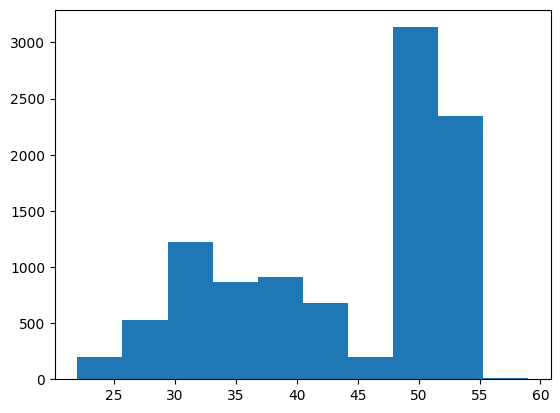

In [232]:
cleaned = clean_prompts(all_prompts)
plt.hist([len(cleaned[i]) for i in range(len(all_prompts))])

(array([ 601.,  574.,  308., 4526.,  191.,  700., 1105.,  620., 1142.,
         330.]),
 array([ 52. ,  59.6,  67.2,  74.8,  82.4,  90. ,  97.6, 105.2, 112.8,
        120.4, 128. ]),
 <BarContainer object of 10 artists>)

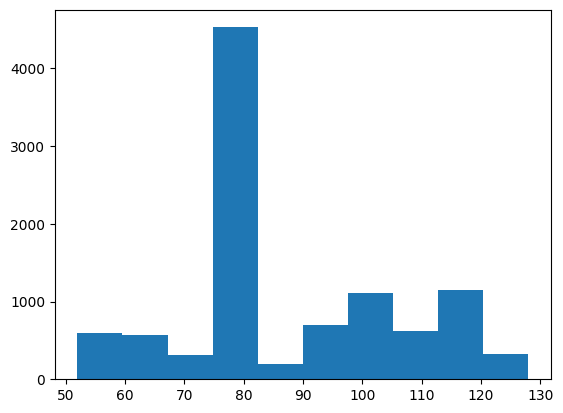

In [234]:
plt.hist([len(all_prompts[i]) for i in range(len(all_prompts))])

In [240]:
count_short = sum(1 for s in all_prompts if len(s) < 55)
print(count_short)

226


In [467]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

embedder = SentenceTransformer('all-distilroberta-v1')

#Plot the principal components of the data in order to see wtf is going on
ds_adversarial = load_dataset("Chetan-k-p/adversarial-prompts")
all_prompts = ds_adversarial['train']['instruction']

threshold = 55 #how many symbols in an adversarial prompt
valid_prompts = [all_prompts[i] for i in range(len(all_prompts)) if len(all_prompts[i]) <= threshold]

train_prompts = clean_prompts([ all_prompts[i] for i in range(2000) ])
test_prompts = embedder.encode(valid_prompts)
train_prompts = embedder.encode(train_prompts)

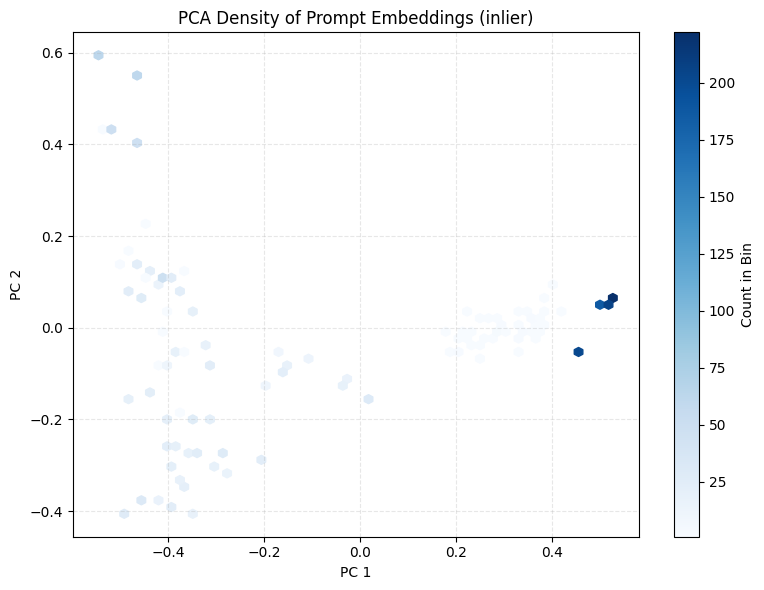

In [468]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(train_prompts) 

plt.figure(figsize=(8, 6))
hb = plt.hexbin(
    pcs[:, 0],
    pcs[:, 1],
    gridsize=60,         # controls the resolution of the hexbins
    cmap='Blues',
    mincnt=1             # only show bins with at least 1 point
)
plt.colorbar(hb, label='Count in Bin')
plt.title("PCA Density of Prompt Embeddings (inlier)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

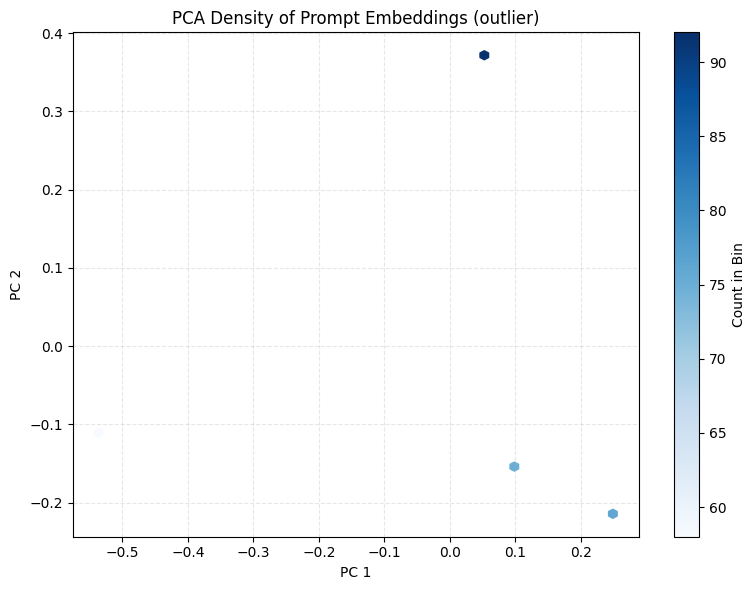

In [469]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(test_prompts) 

plt.figure(figsize=(8, 6))
hb = plt.hexbin(
    pcs[:, 0],
    pcs[:, 1],
    gridsize=60,         # controls the resolution of the hexbins
    cmap='Blues',
    mincnt=1             # only show bins with at least 1 point
)
plt.colorbar(hb, label='Count in Bin')
plt.title("PCA Density of Prompt Embeddings (outlier)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
def clean_prompts(prompts: list):
    cleaned = []
    for prompt in prompts:
        before, _, after = prompt.partition(":")
        cleaned.append(before)
    return cleaned

    
def compute_ebh(E, alpha, min_adaptive=False):
    K = len(E)
    sorted_idx = np.argsort(E)[::-1]
    if min_adaptive:
        if np.mean(E) >= (1 / alpha):
            alpha = alpha * (K / (K - 1))
        else:
            return set()
    for i in range(K, 0, -1):
        threshold = K / (alpha * i)
        if E[sorted_idx[i - 1]] >= threshold:
            return set(sorted_idx[:i])
    return set()

In [165]:
ds = load_dataset("data-is-better-together/10k_prompts_ranked", split='train')['prompt']

(array([9.897e+03, 2.970e+02, 8.400e+01, 1.800e+01, 1.400e+01, 7.000e+00,
        1.100e+01, 2.000e+00, 0.000e+00, 1.000e+00]),
 array([2.00000e+00, 2.18570e+03, 4.36940e+03, 6.55310e+03, 8.73680e+03,
        1.09205e+04, 1.31042e+04, 1.52879e+04, 1.74716e+04, 1.96553e+04,
        2.18390e+04]),
 <BarContainer object of 10 artists>)

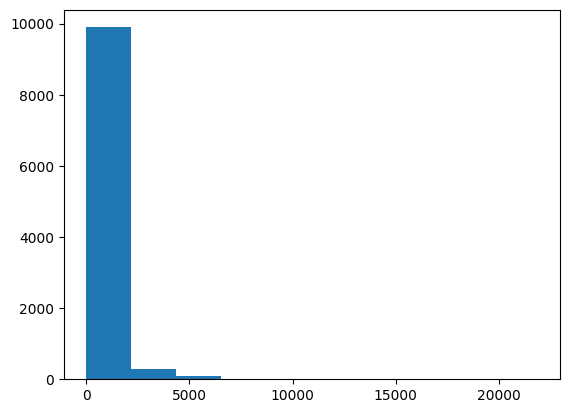

In [167]:
plt.hist([len(ds[i]) for i in range(len(ds))])

In [169]:
from datasets import load_dataset

dataset_adv = load_dataset('TrustAIRLab/in-the-wild-jailbreak-prompts', 'jailbreak_2023_05_07', split='train')['prompt']
ds = load_dataset("data-is-better-together/10k_prompts_ranked", split='train')['prompt']
threshold = np.percentile([len(ds[i]) for i in range(len(ds))], 90)
dataset_adv = [dataset_adv[i].replace("\n", "") for i in range(len(dataset_adv)) if len(dataset_adv[i]) <= threshold]

(array([19., 25., 33., 34., 23., 30., 30., 37., 33., 25.]),
 array([  33. ,  163.6,  294.2,  424.8,  555.4,  686. ,  816.6,  947.2,
        1077.8, 1208.4, 1339. ]),
 <BarContainer object of 10 artists>)

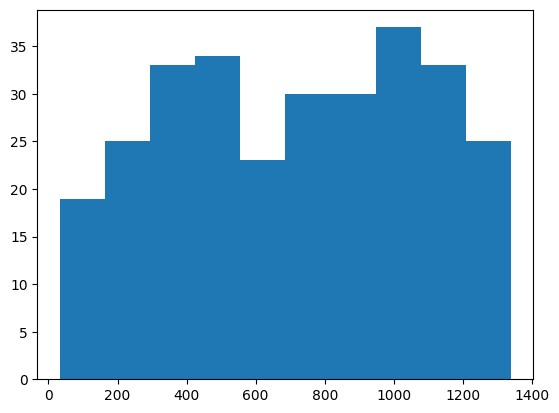

In [171]:
plt.hist([len(dataset_adv[i]) for i in range(len(dataset_adv))])

In [209]:
def subroutine(classifier, Xref, Xtest, blocks, negate_scores=True):
    m = Xtest.shape[0]
    n = Xref.shape[0]
    
    scores = np.zeros(shape=(m,n+m))
    if len(blocks)==1:
        # 1-FC: this is just the default full conformal, without leave-one-out training
        Xaugmented = np.vstack((Xref, Xtest))
        classifier.fit(Xaugmented)
        score_samples = classifier.score_samples(Xaugmented).flatten()
        scores = np.tile(score_samples, (m, 1))
        
        return -1 * scores
    
    for block_idx, block in enumerate(blocks):
        Xaugmented = np.vstack((Xref, Xtest[block]))
        classifier.fit(Xaugmented)
        score_samples = classifier.score_samples(Xaugmented).flatten()
        scores[block,:n] = score_samples[:n]
        
        # D_test[block] next
        test_scores = np.zeros(m)
        test_scores[block] = score_samples[n:]
        
        # D_test[-block] last
        all_but_block = np.setdiff1d(range(m), block)
        test_scores[all_but_block] = classifier.score_samples(Xtest[all_but_block]).flatten()
        scores[block,n:] = test_scores
    return -1 * scores

In [255]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import random
# 'all-mpnet-base-v2' - large space (768)
# 'all-distilroberta-v1' - large space (768)
#'all-MiniLM-L6-v2' - smaller space (384)
embedder = SentenceTransformer('all-distilroberta-v1')

#Getting the adversarial prompts
ds_adversarial = load_dataset("Chetan-k-p/adversarial-prompts")
all_prompts = ds_adversarial['train']['instruction']

#train_prompts = ds
#test_prompts = dataset_adv

train_prompts = clean_prompts(all_prompts)
threshold = np.percentile([len(train_prompts[i]) for i in range(len(train_prompts))], 99) #how many symbols in an adversarial prompt
test_prompts = [all_prompts[i] for i in range(len(all_prompts)) if len(all_prompts[i]) <= threshold]

props_outliers = np.arange(0.2,0.5,0.05)
n = 2000
m = 100
n_exp = 300
alpha_fdr = 0.05
adjustment = 1/(1+alpha_fdr) #1

#Classifier we're going to use
#OneClassSVM(nu=0.004, kernel='rbf', gamma='scale')
#IsolationForest(max_samples=1.0, n_estimators=50)

classifier_KFC = IsolationForest(max_samples=1.0, n_estimators=50)
classifier = OneClassSVM(nu=0.004, kernel='rbf', gamma='scale')

#classifier_name = 'Isolation Forest'

block_range = [5, 10, 20, 50]

for K_blocks in block_range:
    results_power = {'KFC':[], 'Adadetect': [], 'SC': []}
    results_fdr = {'KFC':[], 'Adadetect': [], 'SC': []}
    
    for prop_outliers in props_outliers:
        exp_results_power = {'KFC':[], 'Adadetect': [], 'SC': []}
        exp_results_fdr = {'KFC':[], 'Adadetect': [], 'SC': []}
        for exp in range(n_exp):
            np.random.seed(exp)
            n_outliers = int(np.ceil(m * prop_outliers))
            
            perm0 = np.random.permutation(len(train_prompts))
            Xref = [train_prompts[i] for i in np.sort(perm0[:n]) ]
            
            perm = np.random.permutation(m) 
            nonzero = np.sort(perm[:n_outliers])
            nulls = np.sort(perm[n_outliers:])
            
            # don't generate test dataset under covariate shift
            Xtest0 = [ train_prompts[i] for i in np.sort(perm0[n:n+m-n_outliers]) ]# inliers 
            Xtest1 = random.sample(test_prompts, n_outliers) # outliers
            
            # weights are just ones vector
            test_weights = np.ones(m)
            cal_weights = np.ones(n)
            
            Xtest = np.empty(m, dtype=object)
            Xtest[nonzero] = Xtest1
            Xtest[nulls] = Xtest0
        
            Xref = embedder.encode(Xref)
            Xtest = embedder.encode(Xtest)

            # KFC    
            blocks = np.array_split(np.arange(m), K_blocks)
            baseline_score_matrix = subroutine(classifier_KFC, Xref, Xtest, blocks) 
            e_values_KFC = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
            e_rej = compute_ebh(e_values_KFC, alpha_fdr)            
            
            exp_results_power['KFC'].append(compute_power(e_rej, nonzero))
            exp_results_fdr['KFC'].append(compute_fdp(e_rej, nulls))
            print(f'KFC power {compute_power(e_rej, nonzero)}, KFC FDP {compute_fdp(e_rej, nulls)}')
        
            #Adadetect
            proc = AdaDetectERM(scoring_fn = classifier, split_size=4000/5000) 
            rej = proc.apply(Xtest, alpha_fdr, Xref)
            exp_results_power['Adadetect'].append(compute_power(rej, nonzero))
            exp_results_fdr['Adadetect'].append(compute_fdp(rej, nulls))
        
            #SC 
            train_prop = 0.5   # this is a tuning hyperparameter
            SC_n_train = int(n * train_prop)
            SC_train_split = np.random.permutation(n)
            Xtrain_split = Xref[SC_train_split[:SC_n_train]].copy()
            Xcalib_split = Xref[SC_train_split[SC_n_train:]].copy()
            
            classifier.fit(Xtrain_split)
            calib_scores = classifier.score_samples(Xcalib_split).flatten()
            test_scores = classifier.score_samples(Xtest).flatten()
            
            score_matrix_SC = -1 * np.tile(np.concatenate([calib_scores, test_scores]), (m, 1))
            
            # make split conformal e-values
            split_e_values = e_function_static(adjustment*alpha_fdr, score_matrix_SC, cal_weights[SC_train_split[SC_n_train:]], test_weights)
            split_e_rej = compute_ebh(split_e_values, alpha_fdr)
            
            exp_results_power['SC'].append(compute_power(split_e_rej, nonzero))
            exp_results_fdr['SC'].append(compute_fdp(split_e_rej, nulls))
        
        print('Power KFC', np.mean(exp_results_power['KFC']), 'Power Adadetect', np.mean(exp_results_power['Adadetect']), 
                                                                                        'Power SC', np.mean(exp_results_power['SC']))
        print('FDR KFC', np.mean(exp_results_fdr['KFC']), 'FDR Adadetect', np.mean(exp_results_fdr['Adadetect']), 
                                                                                        'FDR SC', np.mean(exp_results_fdr['SC']))
        results_power['KFC'].append(exp_results_power['KFC'])
        results_power['Adadetect'].append(exp_results_power['Adadetect'])
        results_power['SC'].append(exp_results_power['SC'])
        
        results_fdr['KFC'].append(exp_results_fdr['KFC'])
        results_fdr['Adadetect'].append(exp_results_fdr['Adadetect'])
        results_fdr['SC'].append(exp_results_fdr['SC'])
        
    power_df = pd.DataFrame(results_power).add_prefix('power_')
    fdr_df = pd.DataFrame(results_fdr).add_prefix('fdr_')
    results_df = pd.concat([power_df, fdr_df], axis = 1)
    results_df['props_outliers'] = props_outliers
    results_df.to_csv(f'results_with_{K_blocks}_blocks_{n_exp}.csv', index=False)


KFC power 0.0, KFC FDP 0.0
KFC power 1.0, KFC FDP 0.3548387096774194
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.8, KFC FDP 0.4482758620689655
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.9, KFC FDP 0.3333333333333333
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 0.0, KFC FDP 0.0
KFC power 

KeyboardInterrupt: 

In [265]:
import ast

K_blocks = 10
n_exp = 300
df = pd.read_csv(f'results_with_{K_blocks}_blocks_{n_exp}.csv')
props_outliers = df.pop('props_outliers').values
results_power = df.filter(regex=r'^power_') \
             .rename(columns=lambda c: c[len('power_'):])
results_power = results_power.applymap(lambda s: np.array(ast.literal_eval(s)))
results_fdr  = df.filter(regex=r'^fdr_') \
             .rename(columns=lambda c: c[len('fdr_'):])
results_fdr = results_fdr.applymap(lambda s: np.array(ast.literal_eval(s)))

/var/folders/54/btrgqywd325_yg5yl79r402c0000gn/T/ipykernel_30116/3286245266.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_power = results_power.applymap(lambda s: np.array(ast.literal_eval(s)))
/var/folders/54/btrgqywd325_yg5yl79r402c0000gn/T/ipykernel_30116/3286245266.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_fdr = results_fdr.applymap(lambda s: np.array(ast.literal_eval(s)))


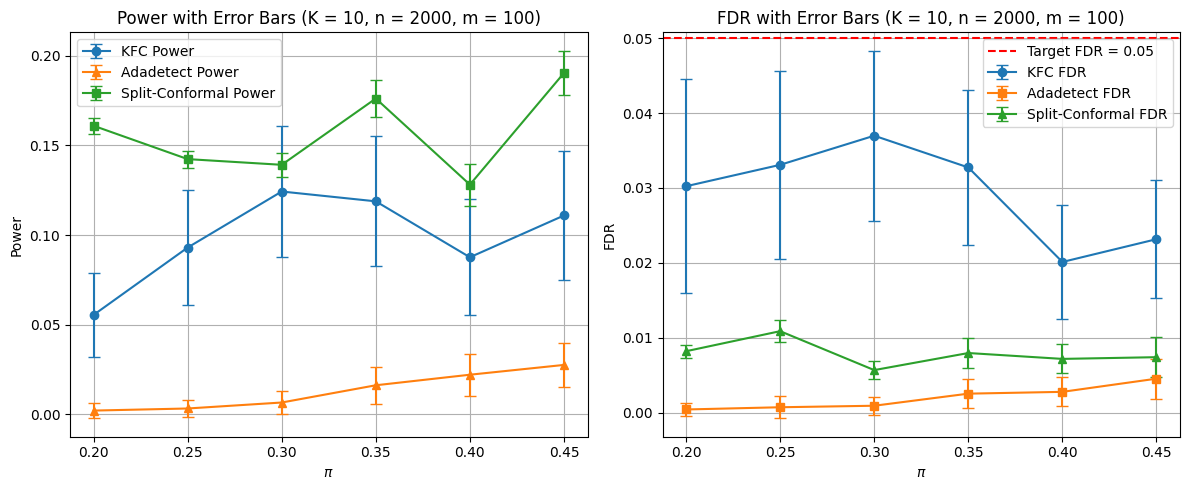

In [267]:
import matplotlib.pyplot as plt

FDR_KFC = []
err_FDR_KFC = []

FDR_Adadetect = []
err_FDR_Adadetect = []

FDR_SC = []
err_FDR_SC = []

power_KFC = []
err_power_KFC = []

power_Adadetect = []
err_power_Adadetect = []

power_SC = []
err_power_SC = []

for idx, pi in enumerate(props_outliers):
    FDR_KFC.append(np.mean(results_fdr['KFC'][idx]))
    FDR_Adadetect.append(np.mean(results_fdr['Adadetect'][idx]))
    FDR_SC.append(np.mean(results_fdr['SC'][idx]))
    
    err_FDR_KFC.append(np.std(results_fdr['KFC'][idx]))
    err_FDR_Adadetect.append(np.std(results_fdr['Adadetect'][idx]))
    err_FDR_SC.append(np.std(results_fdr['Adadetect'][idx]))

    power_KFC.append(np.mean(results_power['KFC'][idx]))
    power_Adadetect.append(np.mean(results_power['Adadetect'][idx]))
    power_SC.append(np.mean(results_power['SC'][idx]))
    
    err_power_KFC.append(np.std(results_power['KFC'][idx]))
    err_power_Adadetect.append(np.std(results_power['Adadetect'][idx]))
    err_power_SC.append(np.std(results_power['Adadetect'][idx]))
    
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot power with error bars
axes[0].errorbar(props_outliers, power_KFC, yerr=2*np.array(err_power_KFC)/np.sqrt(n_exp), fmt='-o', capsize=4, label='KFC Power')
axes[0].errorbar(props_outliers, power_Adadetect, yerr=2*np.array(err_power_Adadetect)/np.sqrt(n_exp), fmt='-^', capsize=4, label='Adadetect Power')
axes[0].errorbar(props_outliers, power_SC, yerr=2*np.array(err_power_SC)/np.sqrt(n_exp), fmt='-s', capsize=4, label='Split-Conformal Power')
axes[0].set_xlabel(r'$\pi$')
axes[0].set_ylabel('Power')
axes[0].set_title(f'Power with Error Bars (K = {K_blocks}, n = {n}, m = {m})')
axes[0].legend()
axes[0].grid(True)

# Plot FDR with error bars
axes[1].errorbar(props_outliers, np.array(FDR_KFC), yerr=2*np.array(err_FDR_KFC)/np.sqrt(n_exp), capsize=4, fmt='-o', label='KFC FDR')
axes[1].errorbar(props_outliers, FDR_Adadetect, yerr=2*np.array(err_FDR_Adadetect)/np.sqrt(n_exp), fmt='-s',capsize=4, label='Adadetect FDR')
axes[1].errorbar(props_outliers, FDR_SC, yerr=2*np.array(err_FDR_SC)/np.sqrt(n_exp),  fmt='-^',capsize=4, label='Split-Conformal FDR')
axes[1].axhline(y=alpha_fdr, color='red', linestyle='--', label=f'Target FDR = {alpha_fdr}')
axes[1].set_xlabel(r'$\pi$')
axes[1].set_ylabel('FDR')
axes[1].set_title(f'FDR with Error Bars (K = {K_blocks}, n = {n}, m = {m})')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [28]:
from utils.multiple_testing import p_function_static
from collections import defaultdict

p_values = p_function_static(baseline_score_matrix, cal_weights, test_weights)
p_rej = eBH(1/p_values, alpha_fdr)
guarantee = True

fold_memberships = {}    # compute which blocks each test point belong to
lofo_fold_dict = {}
for fold_idx, fold in enumerate(blocks):
    for j in fold:
        fold_memberships[j] = fold_idx
    lofo_fold_dict[fold_idx] = [f for idx, f in enumerate(blocks) if idx != fold_idx] # only need to do this slow list comprehension once per fold

## we will CC in ascending order of the p-values --- but there are ties. compute the strata of the p-values
p_values_normalized = np.rint(p_values * (n+1)).astype(int)
sorted_idxs = np.argsort(p_values_normalized)
# sorted_idxs = np.argsort(p_values)

strata = defaultdict(list)
for idx in sorted_idxs:
    strata[p_values_normalized[idx]].append(idx) 

e_boost = np.zeros(m)
 
# now resample the scores
resampled_score_dict = {}

cc_fail_counter = 0
for key in strata:
    p_value_stratum = strata[key]

    cc_fail_inidicator_stratum = 1    # specific fail counter within the stratum, set it to True and make it False if we succeed
    for j in p_value_stratum: #sorted_idxs: #p_value_stratum:

        if guarantee:
            if j in e_rej:
                e_boost[j] = np.inf
                cc_fail_counter = 0 
                continue

        if cc_fail_counter >= 2:
            break 

        # determine which fold contains idx
        fold = blocks[fold_memberships[j]]
        lofo_folds = lofo_fold_dict[fold_memberships[j]]

        # compute the auxiliary statistic we need
        lofo_fold_membership_idxs = np.array([L[0] for L in lofo_folds])
        # specific test point
        Xj = Xtest[j]

        # begin the retraining/resampling steps
        resampled_scores_list = np.zeros((n+1, m, n+m))
        for i in range(n):
            # in this case, Z_i and Z_{n+j} are switched
            # the fold which j belongs to leads to scores which are unchanged by this switch
            # so we only retrain the folds for which j does not belong to
            Xi = Xref[i]

            Xref_resample = np.vstack((Xref[:i], Xj, Xref[(i+1):]))
            Xtest_resample = np.vstack((Xtest[:j], Xi, Xtest[(j+1):]))

            scores_resample = subroutine(Classifier, Xref_resample, Xtest_resample, lofo_folds)  

            # the current fold is not scored yet... but nothing has changed, except we should change i and n+j
            scores_for_current_fold = baseline_score_matrix[fold,:].copy()
            scores_for_current_fold[:, [i, (n+j)]] = scores_for_current_fold[:, [(n+j), i]]

            scores_resample[fold,:] = scores_for_current_fold

            # save the resamples
            resampled_scores_list[i,:,:] = scores_resample
        resampled_scores_list[n,:,:] = real_score_matrix  # when Z_{n+j} is switched with itself, nothing changes

        # now, we make the boosted e-values
        # if we used randomness to make p-values, then this is for integrating out the randomness
        boosting_start_time = time.time()
        if deterministic and randomness != 0:
            # if we want our boosted e-value to be deterministic, we must integrate out the randomness coming from U
            if randomness > 1:
                outer_integral = CC_grid_double( 
                        resampled_scores_list, cal_weights, test_weights, alpha_fdr, 
                        randomness, observed_statistic, hatR_statistic,
                        j
                    )
                e_boost[j] = m/alpha_fdr * outer_integral    # int_0^1 e_j^b(U), in a discrete way
            elif randomness == 1:
                assert False
            else:
                # here, there was no randonmness in the p-value to begin with
                assert False
        else:
            # in this case, we are fine with randomness, and simply returning e_j(U) --- or o/w there was no randomness in the first place
            if randomness > 1 or randomness == 0:
                c_U = observed_statistic(real_score_matrix, cal_weights, test_weights, U, alpha_fdr, j)
                cond_expectation, numerical_error = CC_grid(
                    c_U, 
                    resampled_scores_list, cal_weights, test_weights, alpha_fdr, 
                    randomness, observed_statistic, hatR_statistic,
                    j
                )    # the actual, U-random observed statistic after we sampled U
                hatR_U = hatR_statistic(real_score_matrix, cal_weights, test_weights, U, alpha_fdr, j)   # actual, U-random hatR
                e_boost[j] = m/alpha_fdr * (cond_expectation <= 0) / hatR_U
                
                print(f'**cond_expectation: {cond_expectation}')
                print(f'**hatR={hatR_U}')
            elif randomness == 1:
                assert False
            else:
                # dead branch
                assert False
        if  e_boost[j] > 0:
            cc_fail_inidicator_stratum = 0    # we succeeded in CCing, set the counter to 0 
            print(f"R / indic = {1/ (e_boost[j] / (m/alpha_fdr)):.5f}")
        print(f'total time: {time.time()-start_time_j:.5f}')

    # stratum done
    if cc_fail_inidicator_stratum != 0:
        cc_fail_counter += 1
    else:
        cc_fail_counter = 0

# after CC, e_boost --> boosted rej set
boost_e_rej = eBH(e_boost, alpha_fdr).astype(int)

KeyboardInterrupt: 

In [30]:
response = client.responses.create(
        model="gpt-4o-mini-2024-07-18",
        input="Write a one-sentence bedtime story about a unicorn."
        )
print(response.output_text)

As the moonlit forest whispered secrets, a gentle unicorn named Luna sprinkled stardust over sleeping flowers, ensuring sweet dreams for all creatures in her enchanted realm.


## Simulation with family of functions (and old code)

In [431]:
import numpy as np
import pandas as pd
from utils.subroutines import subroutine_familywise, subroutine
from utils.multiple_testing import eBH, e_function_static
from utils.helper_functions import compute_fdp, compute_power
from utils.generating_data import gen_data

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.svm import OneClassSVM


#HYPERPARAMETERS

alpha_fdr = 0.05
m = 50 #number of points in test
n = 200 #number of points in the calibration
prop_outliers = 0.5 #proportion of outlier (pi) in the experiement
amp = 3.0 #The amplitude in the training data, refer to notes
K_blocks = 20
n_exp = 100

#Baseline model
KFC_classifier = OneClassSVM(nu=0.8, kernel='rbf', gamma='scale')  # initialize base model

#We construct the family of models
model_parameters = [0.1,0.3,0.5,0.7,0.9]
model_family = []

for nu in model_parameters:
    model_family.append(OneClassSVM(nu=nu, kernel='rbf', gamma='scale'))

#We set up important lists
settings = {'amp': 4.0, 'amps': [2.0, 2.5, 3.0, 3.5, 4.0], 'prop_outliers': 0.2, 'props_outliers': [0.1, 0.2, 0.3, 0.4] }
results_power = {'KFC':[], 'Family': []}
results_fdr = {'KFC':[], 'Family': []}

# details
amps = np.arange(2,4,0.2) # we create a range of parameters to visualize power curve
n_train = n # can specify training amount 
adjustment = 1/(1+alpha_fdr)

# The synthetic data
THETA = np.zeros(50) 

#The setting we're planning to investigate
p_theta = 6 
THETA[:p_theta,] = np.array([0.3, 0.3, 0.2, 0.2, 0.1, 0.1]) 
THETA = THETA.reshape((50,1))


# FDR estimation
adjustment = 0.5
amp = settings['amp']
for prop_outliers in settings['props_outliers']:
    fdp_KFC = []
    fdp_family = []
    for exp in range(n_exp):
        np.random.seed(exp)
        #We repeat the same structure of the experiement
        Wset = np.random.uniform(size=(50,50)) * 6 - 3
        n_outliers = int(np.ceil(m * prop_outliers))
        blocks = np.array_split(np.arange(m), K_blocks) 
        
        # generate null and alternative hypotheses
        Xref = gen_data(Wset, n, 1)
        perm = np.random.permutation(m) 
        nonzero = np.sort(perm[:n_outliers])
        nulls = np.sort(perm[n_outliers:])
        
        # don't generate test dataset under covariate shift
        Xtest0 = gen_data(Wset, m-n_outliers, 1)    # inliers 
        Xtest1 = gen_data(Wset, n_outliers, amp)    # outliers
        
        # weights are just ones vector
        test_weights = np.ones(m)
        cal_weights = np.ones(n)
        
        Xtest = np.zeros((m, Xtest0.shape[1]))
        Xtest[nonzero,] = Xtest1
        Xtest[nulls,] = Xtest0

        e_rej_family = subroutine_familywise(model_family, Xref, Xtest, blocks, alpha_fdr)
        baseline_score_matrix = subroutine(KFC_classifier, Xref, Xtest, blocks) 
        print(baseline_score_matrix.shape)
        
        e_values_KFC = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
        print(e_values_KFC)
        e_rej = eBH(e_values_KFC, alpha_fdr)
        print(e_rej)

        fdp_KFC.append(compute_fdp(e_rej, nulls))
        fdp_family.append(compute_fdp(e_rej_family, nulls))
        print(f'{exp}/{n_exp} Done')
    print(f'FDR KFC: {np.mean(fdp_KFC)}, FDR Family: {np.mean(fdp_family)}')
    results_fdr['KFC'].append(fdp_KFC)
    results_fdr['Family'].append(fdp_family)


prop_outliers = settings['prop_outliers']
for amp in settings['amps']:
    power_KFC = []
    power_family = []
    for exp in range(n_exp):
        np.random.seed(exp)
        #We repeat the same structure of the experiement
        Wset = np.random.uniform(size=(50,50)) * 6 - 3
        n_outliers = int(np.ceil(m * prop_outliers))
        blocks = np.array_split(np.arange(m), K_blocks) 
        
        # generate null and alternative hypotheses
        Xref = gen_data(Wset, n, 1)
        perm = np.random.permutation(m) 
        nonzero = np.sort(perm[:n_outliers])
        nulls = np.sort(perm[n_outliers:])
        
        # don't generate test dataset under covariate shift
        Xtest0 = gen_data(Wset, m-n_outliers, 1)    # inliers 
        Xtest1 = gen_data(Wset, n_outliers, amp)    # outliers
        
        # weights are just ones vector
        test_weights = np.ones(m)
        cal_weights = np.ones(n)
        
        Xtest = np.zeros((m, Xtest0.shape[1]))
        Xtest[nonzero,] = Xtest1
        Xtest[nulls,] = Xtest0
        
        e_rej_family =subroutine_familywise(model_family, Xref, Xtest, blocks, alpha_fdr)
        
        baseline_score_matrix = subroutine(KFC_classifier, Xref, Xtest, blocks) 
        e_values_KFC = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
        e_rej = eBH(e_values_KFC, alpha_fdr)

        power_KFC.append(compute_power(e_rej, nonzero))
        power_family.append(compute_power(e_rej_family, nonzero))
        print(f'{exp}/{n_exp} Done')
    print(f'Finished {amp}, Power KFC: {np.mean(power_KFC)}, Power Family: {np.mean(power_family)}')
    results_power['KFC'].append(power_KFC)
    results_power['Family'].append(power_family)

FDR_KFC = []
err_KFC = []

FDR_family = []
err_family = []

power_KFC = []
err_power_KFC = []

power_family = []
err_power_family = []

#Saving the information
for idx, pi in enumerate(settings['props_outliers']):
    FDR_KFC.append(np.mean(results_fdr['KFC'][idx]))
    FDR_family.append(np.mean(results_fdr['Family'][idx]))
    err_KFC.append(np.std(results_fdr['KFC'][idx]))
    err_family.append(np.std(results_fdr['Family'][idx]))
for idx, amp in enumerate(settings['amps']):
    err_power_KFC.append(np.std(results_power['KFC'][idx]))
    err_power_family.append(np.std(results_power['Family'][idx]))
    power_KFC.append(np.mean(results_power['KFC'][idx]))
    power_family.append(np.mean(results_power['Family'][idx]))

#Save the dataframes
df_fdr = pd.DataFrame({
    'props_outliers': settings['props_outliers'],
    'FDR_KFC': FDR_KFC,
    'FDR_family': FDR_family,
    'err_KFC': err_KFC,
    'err_family': err_family
})
df_power = pd.DataFrame({
    'amps': settings['amps'],
    'power_KFC': power_KFC,
    'power_family': power_family,
    'err_power_KFC': err_power_KFC,
    'err_power_family': err_power_family
})

df_combined = pd.concat([df_fdr, df_power], axis=1)
df_combined.to_csv('simulation_results/family_simulation_results.csv', index=False)

(50, 250)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[]
0/100 Done
(50, 250)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[]
1/100 Done
(50, 250)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[]
2/100 Done
(50, 250)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[]
3/100 Done


KeyboardInterrupt: 

In [68]:
import numpy as np
from sklearn.datasets import fetch_openml 
from sklearn.ensemble import RandomForestClassifier
from utils.Adadetect import AdaDetectERM 

dataset = fetch_openml(name='creditcard', version=1, as_frame=False)
X = dataset.data
y = dataset.target.astype(float)

#test sample 
outlr, inlr = X[y==1], X[y==0]
m1 = 100
m0 = 900 
test1, test0 = outlr[:m1], inlr[:m0]
x = np.concatenate([test0, test1]) 

#NTS
n=5000
xnull = inlr[m0:m0+n]
print(xnull)

#apply AdaDetect with ERM approach, with k=4000 (see notations of the paper)
level=0.05
proc = AdaDetectERM(scoring_fn = RandomForestClassifier(max_depth=10),
                                 split_size=4000/5000) 
rej = proc.apply(x, level, xnull) #gives the rejection set 
print(rej)

[[ 1.19481237e+00 -8.81612198e-02  4.87398534e-01 ... -3.56845574e-02
   1.28302983e-02  2.53900000e+01]
 [-1.66552053e+00  4.58385639e-01  1.75327379e+00 ...  2.05525854e-02
   3.21087229e-03  2.49000000e+01]
 [-6.68257138e-01  1.13996896e+00  8.35532995e-01 ...  2.18908675e-02
   1.08543434e-01  8.99500000e+01]
 ...
 [-6.18608536e-01  1.58665475e+00  2.09162594e+00 ...  3.32736239e-01
   1.63765285e-02  1.01800000e+01]
 [ 1.18810214e+00  1.31939536e+00 -1.35247118e+00 ...  5.46019358e-03
   8.16650747e-02  3.58000000e+00]
 [-7.27592569e-01  4.70934409e-01  7.31445102e-01 ...  3.28764754e-01
   2.01526559e-01  2.09570000e+02]]
[977 936 935 968 933 969 970 928 971 925 923 922 972 974 976 916 915 978
 967 910 937 965 953 951 954 950 955 949 948 957 947 958 959 945 961 942
 962 963 964 966 979 952 917 997 996 995 918 927 930 992 934 919 920 909
 998 999 912 913 994 931 983 907 946 980 991 911 944 926 943 990 921 905
 903 908 986 906 929 914 904 973 981 982 975 938 472 900 988]
